In [1]:
# ============================================================
# PROJECT: Predicting Startup Success Using Investment Data
# and Machine Learning
# DATASET: Crunchbase / Startup Investments
# PLATFORM: Kaggle Notebook
# ============================================================

# -----------------------------
# 1. Import libraries
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional: make tables easier to read
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# -----------------------------
# 2. Find dataset files
# -----------------------------
# Kaggle usually stores uploaded/input datasets inside /kaggle/input/
# We will print all files so you can confirm the exact folder name.

base_input = "/kaggle/input"

for root, dirs, files in os.walk(base_input):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/justinas/startup-investments/funding_rounds.csv
/kaggle/input/datasets/justinas/startup-investments/milestones.csv
/kaggle/input/datasets/justinas/startup-investments/acquisitions.csv
/kaggle/input/datasets/justinas/startup-investments/ipos.csv
/kaggle/input/datasets/justinas/startup-investments/relationships.csv
/kaggle/input/datasets/justinas/startup-investments/objects.csv
/kaggle/input/datasets/justinas/startup-investments/offices.csv
/kaggle/input/datasets/justinas/startup-investments/people.csv
/kaggle/input/datasets/justinas/startup-investments/degrees.csv
/kaggle/input/datasets/justinas/startup-investments/investments.csv
/kaggle/input/datasets/justinas/startup-investments/funds.csv


In [3]:
# -----------------------------
# 3. Load dataset files
# -----------------------------

DATA_PATH = "/kaggle/input/datasets/justinas/startup-investments"
objects = pd.read_csv(f"{DATA_PATH}/objects.csv", low_memory=False)
funding_rounds = pd.read_csv(f"{DATA_PATH}/funding_rounds.csv", low_memory=False)
acquisitions = pd.read_csv(f"{DATA_PATH}/acquisitions.csv", low_memory=False)

print("Objects shape:", objects.shape)
print("Funding rounds shape:", funding_rounds.shape)
print("Acquisitions shape:", acquisitions.shape)

objects.head()

Objects shape: (462651, 40)
Funding rounds shape: (52928, 23)
Acquisitions shape: (9562, 12)


,id,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,founded_at,closed_at,domain,homepage_url,twitter_username,logo_url,logo_width,logo_height,short_description,description,overview,tag_list,country_code,state_code,city,region,first_investment_at,last_investment_at,investment_rounds,invested_companies,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at
0,c:1,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,http://wetpaint-inc.com,BachelrWetpaint,http://s3.amazonaws.com/crunchbase_prod_assets...,401,54,NaN,Technology Platform Company,Wetpaint is a technology platform company that...,"wiki, seattle, elowitz, media-industry, media-...",USA,WA,Seattle,Seattle,NaN,NaN,0,0,2005-10-01,2008-05-19,3,39750000.0,2010-09-05,2013-09-18,5,17,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00
1,c:10,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,NaN,NaN,flektor.com,http://www.flektor.com,NaN,http://s3.amazonaws.com/crunchbase_prod_assets...,186,85,NaN,NaN,Flektor is a rich-media mash-up platform that ...,"flektor, photo, video",USA,CA,Culver City,Los Angeles,NaN,NaN,0,0,NaN,NaN,0,0.0,NaN,NaN,0,6,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14
2,c:100,Company,100,NaN,There,there,/company/there,games_video,acquired,NaN,NaN,there.com,http://www.there.com,NaN,http://s3.amazonaws.com/crunchbase_prod_assets...,107,34,NaN,NaN,There.com is an online virtual world where any...,"virtualworld, there, teens",USA,CA,San Mateo,SF Bay,NaN,NaN,0,0,NaN,NaN,0,0.0,2003-02-01,2011-09-23,4,12,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48
3,c:10000,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,2008-07-26,NaN,mywebbo.com,http://www.mywebbo.com,NaN,NaN,0,0,NaN,NaN,"BRAND NEW ONLINE SOCIAL NETWORKING WEBSITE,FOR...","social-network, new, website, web, friends, ch...",NaN,NaN,NaN,unknown,NaN,NaN,0,0,NaN,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18
4,c:10001,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,2008-07-26,NaN,themoviestreamer.com,http://themoviestreamer.com,NaN,http://s3.amazonaws.com/crunchbase_prod_assets...,200,74,NaN,NaN,This company shows free movies online on their...,"watch, full-length, moives, online, for, free,...",NaN,NaN,NaN,unknown,NaN,NaN,0,0,NaN,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18


In [4]:
acquired_ids = set(acquisitions["acquired_object_id"])

objects["acquired"] = objects["id"].isin(acquired_ids).astype(int)

objects[["name","category_code","country_code","acquired"]].head()

,name,category_code,country_code,acquired
0,Wetpaint,web,USA,0
1,Flektor,games_video,USA,1
2,There,games_video,USA,1
3,MYWEBBO,network_hosting,NaN,0
4,THE Movie Streamer,games_video,NaN,0


In [5]:
# -----------------------------
# Aggregate funding data
# -----------------------------

funding_rounds["raised_amount_usd"] = pd.to_numeric(
    funding_rounds["raised_amount_usd"], errors="coerce"
)

funding_agg = funding_rounds.groupby("object_id").agg(
    total_funding=("raised_amount_usd","sum"),
    funding_rounds=("raised_amount_usd","count")
).reset_index()

funding_agg.head()

,object_id,total_funding,funding_rounds
0,c:1,39750000.0,3
1,c:1001,5000000.0,1
2,c:10014,0.0,1
3,c:10015,68069200.0,5
4,c:100155,10125293.0,3


In [6]:
print("objects" in globals())
print("funding_agg" in globals())
print("data" in globals())

True
True
False


In [7]:
funding_rounds["raised_amount_usd"] = pd.to_numeric(
    funding_rounds["raised_amount_usd"], errors="coerce"
)

funding_agg = funding_rounds.groupby("object_id").agg(
    total_funding=("raised_amount_usd", "sum"),
    funding_rounds=("raised_amount_usd", "count")
).reset_index()

funding_agg.head()

,object_id,total_funding,funding_rounds
0,c:1,39750000.0,3
1,c:1001,5000000.0,1
2,c:10014,0.0,1
3,c:10015,68069200.0,5
4,c:100155,10125293.0,3


In [8]:
data = objects.merge(
    funding_agg,
    left_on="id",
    right_on="object_id",
    how="left"
)

data = data.rename(columns={"funding_rounds_y": "funding_rounds_total"})

data["total_funding"] = data["total_funding"].fillna(0)
data["funding_rounds_total"] = data["funding_rounds_total"].fillna(0)

data[["name", "total_funding", "funding_rounds_total", "acquired"]].head()

,name,total_funding,funding_rounds_total,acquired
0,Wetpaint,39750000.0,3.0,0
1,Flektor,0.0,0.0,1
2,There,0.0,0.0,1
3,MYWEBBO,0.0,0.0,0
4,THE Movie Streamer,0.0,0.0,0


In [9]:
features = [
    "total_funding",
    "funding_rounds_total",
    "category_code",
    "country_code"
]

data_ml = data[features + ["acquired"]].dropna()

X = data_ml[features]
y = data_ml["acquired"]

print(X.columns)
print(X.shape, y.shape)

Index(['total_funding', 'funding_rounds_total', 'category_code',
       'country_code'],
      dtype='object')
(81218, 4) (81218,)


In [10]:
X = pd.get_dummies(X, columns=["category_code", "country_code"])
print(X.columns[:10])

Index(['total_funding', 'funding_rounds_total', 'category_code_advertising',
       'category_code_analytics', 'category_code_automotive',
       'category_code_biotech', 'category_code_cleantech',
       'category_code_consulting', 'category_code_design',
       'category_code_ecommerce'],
      dtype='object')


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9331445456784043
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     15163
           1       0.14      0.00      0.00      1081

    accuracy                           0.93     16244
   macro avg       0.54      0.50      0.48     16244
weighted avg       0.88      0.93      0.90     16244

[[15157     6]
 [ 1080     1]]


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7300541738488057
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     15163
           1       0.11      0.45      0.18      1081

    accuracy                           0.73     16244
   macro avg       0.53      0.60      0.51     16244
weighted avg       0.89      0.73      0.79     16244

[[11371  3792]
 [  593   488]]


In [14]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.933145
1,Random Forest,0.730054


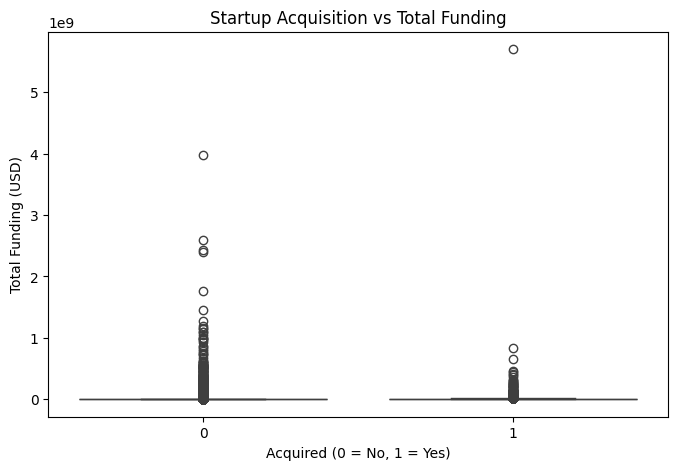

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x=data_ml["acquired"],
    y=data_ml["total_funding"]
)

plt.title("Startup Acquisition vs Total Funding")
plt.xlabel("Acquired (0 = No, 1 = Yes)")
plt.ylabel("Total Funding (USD)")

plt.show()

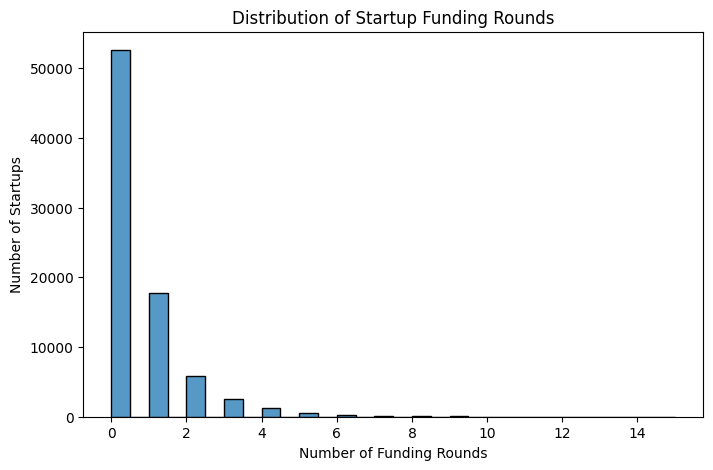

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    data_ml["funding_rounds_total"],
    bins=30
)

plt.title("Distribution of Startup Funding Rounds")
plt.xlabel("Number of Funding Rounds")
plt.ylabel("Number of Startups")

plt.show()

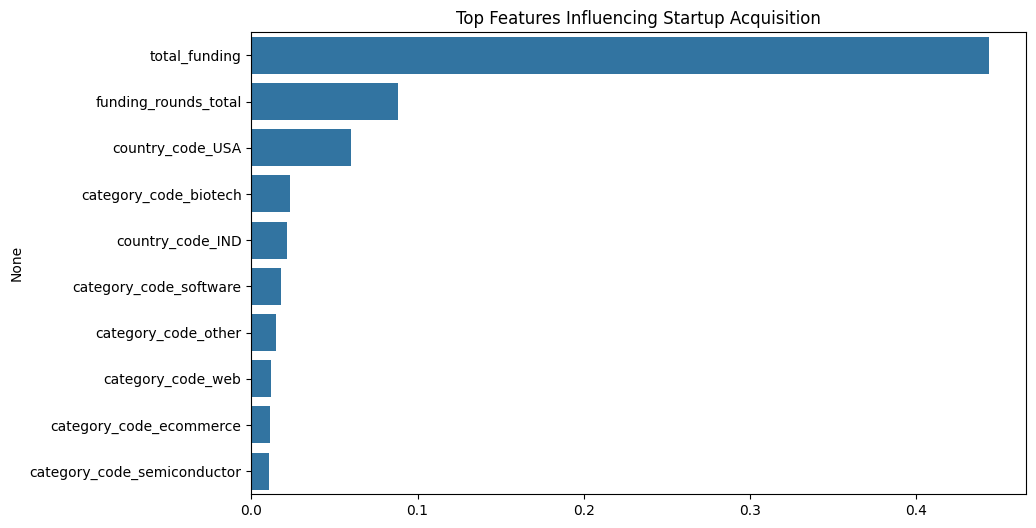

In [17]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Features Influencing Startup Acquisition")

plt.show()